<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/Market_Research_Colab-cftc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market Research Notebook (Google Colab)

Research only — this notebook does not place trades. Update the configuration cell, then run all cells. Free-data sources can be delayed or incomplete; verify with your broker and the original source.

In [ ]:
# Run once in Google Colab
%pip -q install yfinance pandas matplotlib requests

In [ ]:
# --- Configuration ---
SYMBOL = 'SPY'                 # Examples: SPY, BTC-USD, BTC=F, CL=F, GC=F, NG=F
BENCHMARK = 'SPY'
COT_CONTRACT = ''             # e.g. CRUDE OIL, GOLD, BITCOIN, S&P 500 (optional)
PIVOT_DAYS = 20
VOLUME_MULTIPLE = 1.5
ACCOUNT_SIZE = 10_000
RISK_PER_TRADE_PCT = 0.5
STOP_PRICE = None             # e.g. 620.00; None skips position-size calculation
FMP_API_KEY = ''              # optional: Financial Modeling Prep economic-calendar key

In [ ]:
import io
from datetime import date, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import yfinance as yf

def history(symbol, period='2y'):
    df = yf.Ticker(symbol).history(period=period, auto_adjust=False)
    if df.empty: raise ValueError(f'No price data returned for {symbol}')
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.dropna(subset=['Close'])

def enrich(df):
    x = df.copy()
    for n in (20, 50, 200):
        x[f'SMA{n}'] = x.Close.rolling(n).mean()
        x[f'Distance SMA{n} %'] = (x.Close / x[f'SMA{n}'] - 1) * 100
    x['Average Volume 20'] = x.Volume.rolling(20).mean()
    x['Volume Ratio'] = x.Volume / x['Average Volume 20']
    x['Prior Resistance'] = x.High.rolling(PIVOT_DAYS).max().shift(1)
    x['Prior Support'] = x.Low.rolling(PIVOT_DAYS).min().shift(1)
    x['Breakout'] = (x.Close > x['Prior Resistance']) & (x['Volume Ratio'] >= VOLUME_MULTIPLE)
    x['Breakdown'] = (x.Close < x['Prior Support']) & (x['Volume Ratio'] >= VOLUME_MULTIPLE)
    tr = pd.concat([x.High-x.Low, (x.High-x.Close.shift()).abs(), (x.Low-x.Close.shift()).abs()], axis=1).max(axis=1)
    x['ATR14'] = tr.rolling(14).mean()
    x['Realized Volatility 20d %'] = x.Close.pct_change().rolling(20).std() * np.sqrt(252) * 100
    return x

def trend(row):
    if row.Close > row.SMA20 > row.SMA50 > row.SMA200: return 'Bullish alignment'
    if row.Close < row.SMA20 < row.SMA50 < row.SMA200: return 'Bearish alignment'
    return 'Mixed / transition'

--- Technical Analysis for SPY ---
Last Close Price: $771.35
Current Trend: Bullish alignment. This suggests a strong uptrend (short-term SMAs > long-term SMAs, price > all SMAs).
Benchmark (SPY) Trend: Bullish alignment.
Price vs. SMA20: 0.78%
Price vs. SMA50: 1.28%
Price vs. SMA200: 7.36%
Volume Ratio (Current vs Avg 20d): 0.84x
  (Note: Volume is below the conviction threshold.)
14-day Average True Range (ATR): 6.86 (measure of average daily price movement)
20-day Realized Volatility (Annualized): 10.80%
20-day Relative Performance vs SPY: +0.00% (SPY has performed in line with the benchmark.)

**Signal: No volume-confirmed pivot break**
  (No clear volume-confirmed pivot break currently. The asset may be consolidating or lacking strong directional momentum. Look for consolidation patterns or re-tests of support/resistance.)

--- Price Chart ---
The chart below visually represents SPY's price action, moving averages, and key pivot levels (prior resistance/support).


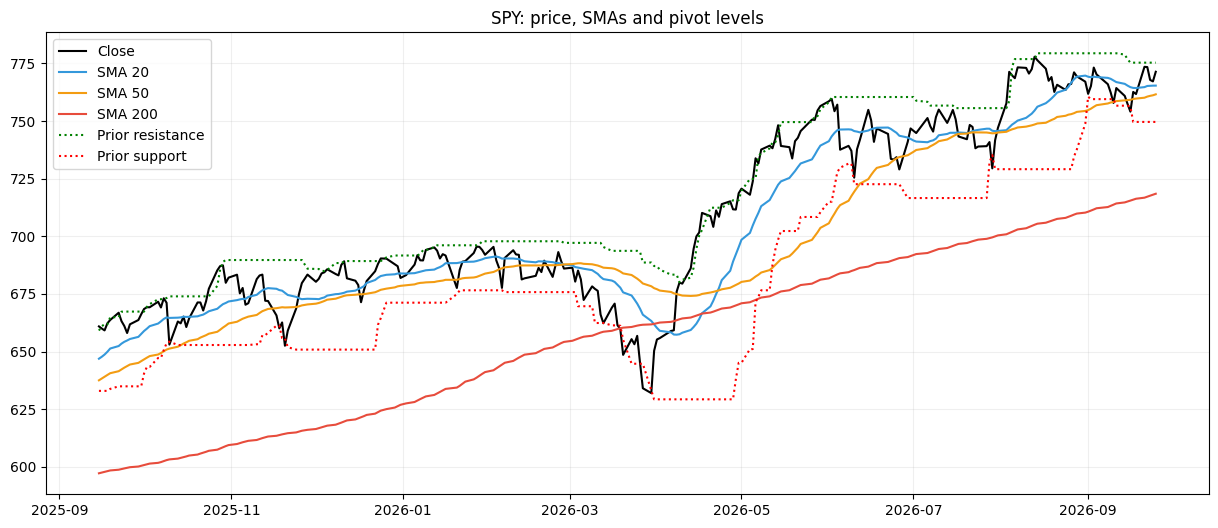

In [ ]:
prices = enrich(history(SYMBOL))
benchmark = enrich(history(BENCHMARK))
last, index_last = prices.iloc[-1], benchmark.iloc[-1]
relative_20d = (prices.Close.iloc[-1]/prices.Close.iloc[-21]-1) - (benchmark.Close.iloc[-1]/benchmark.Close.iloc[-21]-1)
signal = 'CONFIRMED UPSIDE BREAKOUT' if last.Breakout else 'CONFIRMED DOWNSIDE BREAKDOWN' if last.Breakdown else 'No volume-confirmed pivot break'

print(f"--- Technical Analysis for {SYMBOL} ---")
print(f"Last Close Price: ${last.Close:.2f}")

# Trend Analysis
current_trend_msg = f"Current Trend: {trend(last)}."
if 'Bullish alignment' in trend(last):
    current_trend_msg += " This suggests a strong uptrend (short-term SMAs > long-term SMAs, price > all SMAs)."
elif 'Bearish alignment' in trend(last):
    current_trend_msg += " This indicates a strong downtrend (short-term SMAs < long-term SMAs, price < all SMAs)."
else:
    current_trend_msg += " This implies a consolidating or transitioning market."
print(current_trend_msg)

index_regime_msg = f"Benchmark ({BENCHMARK}) Trend: {trend(index_last)}."
print(index_regime_msg)

# Price vs. Moving Averages
print(f"Price vs. SMA20: {last['Distance SMA20 %']:.2f}%")
print(f"Price vs. SMA50: {last['Distance SMA50 %']:.2f}%")
print(f"Price vs. SMA200: {last['Distance SMA200 %']:.2f}%")
if abs(last['Distance SMA20 %']) > 2 and 'alignment' in trend(last):
    print("  (Note: Price is showing strong deviation from its 20-day SMA, indicating recent momentum or potential overextension.)")

# Volume Analysis
print(f"Volume Ratio (Current vs Avg 20d): {last['Volume Ratio']:.2f}x")
if last['Volume Ratio'] >= VOLUME_MULTIPLE:
    print(f"  (Actionable: Current volume is {VOLUME_MULTIPLE}x or more above average, confirming strong conviction in recent price movement.)")
else:
    print("  (Note: Volume is below the conviction threshold.)")

# Volatility
print(f"14-day Average True Range (ATR): {last.ATR14:.2f} (measure of average daily price movement)")
print(f"20-day Realized Volatility (Annualized): {last['Realized Volatility 20d %']:.2f}%")

# Relative Strength
relative_return_msg = f"20-day Relative Performance vs {BENCHMARK}: {relative_20d:+.2%}"
if relative_20d > 0.01: # Outperformance threshold
    relative_return_msg += f" ({SYMBOL} has notably outperformed the benchmark.)"
elif relative_20d < -0.01: # Underperformance threshold
    relative_return_msg += f" ({SYMBOL} has notably underperformed the benchmark.)"
else:
    relative_return_msg += f" ({SYMBOL} has performed in line with the benchmark.)"
print(relative_return_msg)

# Key Signal
print(f"\n**Signal: {signal}**")
if 'UPSIDE BREAKOUT' in signal:
    print(f"  (Actionable: A confirmed upside breakout above prior resistance suggests potential for further upward movement. Consider long entry with a stop below the breakout level.)")
elif 'DOWNSIDE BREAKDOWN' in signal:
    print(f"  (Actionable: A confirmed downside breakdown below prior support suggests potential for further downward movement. Consider short entry or exiting long positions with a stop above the breakdown level.)")
else:
    print("  (No clear volume-confirmed pivot break currently. The asset may be consolidating or lacking strong directional momentum. Look for consolidation patterns or re-tests of support/resistance.)")

print("\n--- Price Chart ---")
print(f"The chart below visually represents {SYMBOL}'s price action, moving averages, and key pivot levels (prior resistance/support).")

plt.figure(figsize=(15,6))
plt.plot(prices.index[-260:], prices.Close.tail(260), label='Close', color='black')
for n, color in [(20,'#3498db'), (50,'#f39c12'), (200,'#e74c3c')]: plt.plot(prices.index[-260:], prices[f'SMA{n}'].tail(260), label=f'SMA {n}', color=color)
plt.plot(prices.index[-260:], prices['Prior Resistance'].tail(260), label='Prior resistance', ls=':', color='green')
plt.plot(prices.index[-260:], prices['Prior Support'].tail(260), label='Prior support', ls=':', color='red')
plt.title(f'{SYMBOL}: price, SMAs and pivot levels'); plt.legend(); plt.grid(alpha=.2); plt.show()

if STOP_PRICE:
    unit_risk = abs(last.Close - STOP_PRICE); max_loss = ACCOUNT_SIZE * RISK_PER_TRADE_PCT / 100
    if unit_risk > 0:
        print(f'\n--- Risk Management ---')
        print(f'Risk Plan: Max loss per trade ${max_loss:,.2f} ({RISK_PER_TRADE_PCT}% of account).')
        print(f'With a stop price of ${STOP_PRICE:.2f} (unit risk ${unit_risk:,.2f}), you could take up to {int(max_loss/unit_risk):,} shares/units.')
        print('For futures, divide by the contract multiplier and allow for slippage/gaps.')
    else:
        print(f'\n--- Risk Management ---')
        print(f'STOP_PRICE is set to {STOP_PRICE}, which results in zero unit risk. Please ensure STOP_PRICE is different from current Close price for a valid calculation.')

In [ ]:
ticker = yf.Ticker(SYMBOL)
try:
    expiries = ticker.options
    if not expiries: raise ValueError('No listed options returned')
    chain = ticker.option_chain(expiries[0]); calls, puts = chain.calls.copy(), chain.puts.copy()
    calls['Type'], puts['Type'] = 'Call', 'Put'
    options = pd.concat([calls, puts])[['Type','strike','lastPrice','bid','ask','volume','openInterest','impliedVolatility']]
    put_call = puts.openInterest.fillna(0).sum() / calls.openInterest.fillna(0).sum()

    print(f'--- Options Chain Analysis for {SYMBOL} (Nearest Expiry: {expiries[0]}) ---')
    print(f'Put/Call Open Interest Ratio: {put_call:.2f}')

    # Interpretation of Put/Call Ratio
    if put_call > 1.2:
        print(f"  (Actionable Insight: A high Put/Call OI Ratio ({put_call:.2f}) suggests a bearish sentiment or significant hedging for downside protection. Watch for potential support or exhaustion of sellers.)")
    elif put_call < 0.8:
        print(f"  (Actionable Insight: A low Put/Call OI Ratio ({put_call:.2f}) suggests a bullish sentiment or high demand for upside exposure. Watch for potential resistance or exhaustion of buyers.)")
    else:
        print(f"  (Insight: The Put/Call OI Ratio ({put_call:.2f}) is relatively neutral, indicating balanced sentiment or hedging.)")

    # Key Strikes by Open Interest
    print("\nKey Options Strikes by Open Interest:")
    top_calls_oi = options[options['Type'] == 'Call'].nlargest(3, 'openInterest')
    top_puts_oi = options[options['Type'] == 'Put'].nlargest(3, 'openInterest')

    if not top_calls_oi.empty:
        print("  Top Call OI Strikes (Potential Resistance Levels/Price Targets):")
        for _, row in top_calls_oi.iterrows():
            print(f"    - Strike: ${row['strike']:.2f}, Open Interest: {row['openInterest']:.0f} (Implied Volatility: {row['impliedVolatility']:.2f})")
    if not top_puts_oi.empty:
        print("  Top Put OI Strikes (Potential Support Levels/Hedging Areas):")
        for _, row in top_puts_oi.iterrows():
            print(f"    - Strike: ${row['strike']:.2f}, Open Interest: {row['openInterest']:.0f} (Implied Volatility: {row['impliedVolatility']:.2f})")

    # Implied Volatility Context
    avg_iv_calls = options[options['Type'] == 'Call']['impliedVolatility'].mean()
    avg_iv_puts = options[options['Type'] == 'Put']['impliedVolatility'].mean()
    print(f"\nAverage Implied Volatility (IV): Calls: {avg_iv_calls:.2f}, Puts: {avg_iv_puts:.2f}")
    print("  (Insight: Higher IV implies the market expects larger price swings, leading to more expensive options. Consider if current IV is high/low historically for strategy selection.)")
    if avg_iv_calls > avg_iv_puts * 1.1:
        print("  (Actionable Insight: Call IV is notably higher than Put IV, indicating a premium for upside protection/speculation. Could suggest bullish bias or demand for call spreads.)")
    elif avg_iv_puts > avg_iv_calls * 1.1:
        print("  (Actionable Insight: Put IV is notably higher than Call IV, indicating a premium for downside protection/speculation. Could suggest bearish bias or demand for put spreads.)")


    print("\n--- Full Options Chain Data ---")
    display(options.sort_values(['Type','strike']))

except Exception as exc:
    print(f'Options data unavailable for {SYMBOL}: {exc}. BTC-USD normally has no Yahoo Finance option chain; consider an ETF such as IBIT for listed options.')

--- Options Chain Analysis for SPY (Nearest Expiry: 2026-09-28) ---
Put/Call Open Interest Ratio: 1.08
  (Insight: The Put/Call OI Ratio (1.08) is relatively neutral, indicating balanced sentiment or hedging.)

Key Options Strikes by Open Interest:
  Top Call OI Strikes (Potential Resistance Levels/Price Targets):
    - Strike: $787.00, Open Interest: 16237 (Implied Volatility: 0.10)
    - Strike: $780.00, Open Interest: 12685 (Implied Volatility: 0.08)
    - Strike: $770.00, Open Interest: 5897 (Implied Volatility: 0.08)
  Top Put OI Strikes (Potential Support Levels/Hedging Areas):
    - Strike: $735.00, Open Interest: 8975 (Implied Volatility: 0.21)
    - Strike: $655.00, Open Interest: 6535 (Implied Volatility: 0.55)
    - Strike: $760.00, Open Interest: 6497 (Implied Volatility: 0.10)

Average Implied Volatility (IV): Calls: 0.23, Puts: 0.31
  (Insight: Higher IV implies the market expects larger price swings, leading to more expensive options. Consider if current IV is high/low h

,Type,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility
0,Call,605.0,153.40,165.41,167.71,NaN,0.0,1.130864
1,Call,610.0,148.38,160.36,162.69,NaN,0.0,1.072270
2,Call,615.0,143.38,155.37,157.69,NaN,0.0,1.042974
3,Call,620.0,138.38,150.40,152.77,NaN,0.0,1.043950
4,Call,645.0,119.39,125.40,127.71,36.0,9.0,0.860353
...,...,...,...,...,...,...,...,...
125,Put,820.0,48.22,47.30,49.72,274.0,NaN,0.462164
126,Put,825.0,53.20,52.30,54.65,86.0,NaN,0.489263
127,Put,830.0,58.08,57.30,59.63,52.0,NaN,0.520757
128,Put,835.0,63.97,62.30,64.65,66.0,NaN,0.555913


In [ ]:
# Official CFTC Legacy futures-only positioning (weekly, delayed)
if COT_CONTRACT:
    url = 'https://www.cftc.gov/dea/newcot/deacot.txt'
    cot = pd.read_csv(io.StringIO(requests.get(url, timeout=30).text))
    name_col = next(c for c in cot.columns if 'Market_and_Exchange_Names' in c)
    matches = cot[cot[name_col].str.contains(COT_CONTRACT, case=False, na=False)].copy()
    cols = [c for c in [name_col, 'As_of_Date_In_Form_YYYY-MM-DD', 'Open_Interest_All', 'Noncommercial_Positions_Long_All', 'Noncommercial_Positions_Short_All', 'Commercial_Positions_Long_All', 'Commercial_Positions_Short_All'] if c in matches]
    display(matches.sort_values('As_of_Date_In_Form_YYYY-MM-DD', ascending=False)[cols].head(12))
else:
    print('Set COT_CONTRACT to fetch CFTC context. COT is released Friday for prior Tuesday positioning; use it as context, not a real-time trigger.')

Set COT_CONTRACT to fetch CFTC context. COT is released Friday for prior Tuesday positioning; use it as context, not a real-time trigger.


In [ ]:
# Cross-market context: breadth, VIX, rates proxy, dollar trend, and BTC perpetuals
sectors = ['XLK','XLF','XLE','XLV','XLY','XLP','XLI','XLB','XLU','XLRE']
breadth = []
for s in sectors:
    d = history(s, '1y'); sma = d.Close.rolling(50).mean().iloc[-1]
    breadth.append([s, d.Close.iloc[-1] > sma, (d.Close.iloc[-1]/sma-1)*100])
breadth = pd.DataFrame(breadth, columns=['Sector ETF','Above SMA50','Distance SMA50 %'])
vix = history('^VIX','1y').Close.iloc[-1]; tnx = history('^TNX','1y').Close.iloc[-1]; dxy = history('DX-Y.NYB','1y').Close
print(f'Sector breadth: {breadth["Above SMA50"].mean():.0%} above SMA50 | VIX: {vix:.2f} | 10Y yield proxy: {tnx:.2f} | Dollar 20d change: {dxy.iloc[-1]/dxy.iloc[-21]-1:+.2%}')
display(breadth)

if SYMBOL.startswith('BTC'):
    try:
        funding = requests.get('https://fapi.binance.com/fapi/v1/fundingRate', params={'symbol':'BTCUSDT','limit':1}, timeout=15).json()[-1]
        oi = requests.get('https://fapi.binance.com/fapi/v1/openInterest', params={'symbol':'BTCUSDT'}, timeout=15).json()
        print(f"BTC perpetual funding: {float(funding['fundingRate'])*100:+.4f}% | One-venue open interest: {float(oi['openInterest']):,.0f} BTC")
    except Exception as exc: print('BTC derivatives unavailable:', exc)

print('For commodity trades, separately add product-specific inventory, weather, crop-condition, shipping and futures-curve data. There is no single proxy that safely covers every commodity.')

Sector breadth: 30% above SMA50 | VIX: 14.87 | 10Y yield proxy: 5.18 | Dollar 20d change: +1.83%


,Sector ETF,Above SMA50,Distance SMA50 %
0,XLK,True,6.396591
1,XLF,False,-3.866717
2,XLE,True,0.460201
3,XLV,True,1.785751
4,XLY,False,-3.713008
5,XLP,False,-3.125121
6,XLI,False,-4.204916
7,XLB,False,-3.672441
8,XLU,False,-8.679919
9,XLRE,False,-6.250279


For commodity trades, separately add product-specific inventory, weather, crop-condition, shipping and futures-curve data. There is no single proxy that safely covers every commodity.


In [ ]:
# Optional: next 31 days of economic events (Financial Modeling Prep API key required)
if FMP_API_KEY:
    params = {'from': date.today().isoformat(), 'to': (date.today()+timedelta(days=31)).isoformat(), 'apikey': FMP_API_KEY}
    response = requests.get('https://financialmodelingprep.com/stable/economic-calendar', params=params, timeout=30)
    response.raise_for_status() # Raise an exception for HTTP errors
    events = pd.DataFrame(response.json())

    if not events.empty:
        # Ensure 'impact' column exists and handle potential NaNs
        if 'impact' in events.columns:
            events['impact'] = events['impact'].fillna('Low')
            # Filter for events with 'High' or 'Medium' impact
            important_events = events[events['impact'].isin(['High', 'Medium'])].copy()
            # Sort by date and impact for better readability
            important_events = important_events.sort_values(by=['date', 'impact'], ascending=[True, False])

            if not important_events.empty:
                print('--- Upcoming High/Medium Impact Economic Events ---')
                for _, row in important_events.iterrows():
                    event_date = pd.to_datetime(row['date']).strftime('%Y-%m-%d')
                    country = row.get('country', 'N/A')
                    event_name = row.get('event', 'N/A')
                    impact = row.get('impact', 'N/A')

                    output_str = f"Date: {event_date}, Country: {country}, Event: {event_name}, Impact: {impact}"

                    # Check for actual vs. estimate/previous and highlight surprises
                    actual = pd.to_numeric(row.get('actual'), errors='coerce')
                    estimate = pd.to_numeric(row.get('estimate'), errors='coerce')
                    previous = pd.to_numeric(row.get('previous'), errors='coerce')

                    surprise_info = []
                    if not pd.isna(actual) and not pd.isna(estimate):
                        deviation = actual - estimate
                        if deviation != 0:
                            surprise_info.append(f"Actual: {actual}, Estimate: {estimate} (Deviation: {deviation:+.2f})")
                    elif not pd.isna(actual) and not pd.isna(previous):
                         deviation = actual - previous
                         if deviation != 0:
                            surprise_info.append(f"Actual: {actual}, Previous: {previous} (Deviation: {deviation:+.2f})")

                    if surprise_info:
                        output_str += " -> " + "; ".join(surprise_info) + " (Potential market surprise)"
                    else:
                        if not pd.isna(actual):
                            output_str += f", Actual: {actual}"
                        if not pd.isna(estimate):
                            output_str += f", Estimate: {estimate}"
                        if not pd.isna(previous):
                            output_str += f", Previous: {previous}"

                    print(output_str)
                print('\nConsider how these events might influence market sentiment or specific sectors relevant to your investment.')
            else:
                print('No high or medium impact economic events found for the next 31 days.')
        else:
            print('Economic events retrieved, but no "impact" column to filter by. Displaying all events:')
            display(events[[c for c in ['date','country','event','impact','actual','previous','estimate'] if c in events.columns]])
    else:
        print('No economic events retrieved for the next 31 days.')
else:
    print('Set FMP_API_KEY in the configuration cell to retrieve the economic calendar.')

Set FMP_API_KEY in the configuration cell to retrieve the economic calendar.
